## Web Scraping & Data Processing Pipeline

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Scraping The Data

In [5]:
from datalink.scraper import TGJUScraper

scraper = TGJUScraper(headless=True, max_pages=3) # collect data over past 3 months
raw_data = scraper.load_or_scrape()               # loads cached data upon subsequent executions

raw_data.head()

2026-08-06 14:09:12,447 - INFO - Reading cached data from D:\Source\svm-using-hmm\datalink\cache\gold18_history.csv


,Reopened,Lowest,Highest,Final,Change_Amount,Change_Percent,Date_Miladi,Date_Jalali
0,"183,221,000","183,201,000","197,711,000","197,631,000",10000,0.01%,2026/08/05,1405/05/14
1,"197,621,000","182,151,000","197,711,000","197,621,000",10000,0.01%,2026/08/04,1405/05/13
2,"197,621,000","183,281,000","197,711,000","197,631,000",50000,0.03%,2026/08/03,1405/05/12
3,"197,701,000","183,061,000","197,711,000","197,681,000",10020000,5.34%,2026/08/02,1405/05/11
4,"197,691,000","186,291,000","197,711,000","187,661,000",9970000,5.31%,2026/08/01,1405/05/10


### Processing & Calculating Log-Returns

In [6]:
from datalink.processor import calculate_tgju_log_returns

log_returns = raw_data.pipe(calculate_tgju_log_returns)

log_returns.head()

,Date,Final_F,Log_Return
89,2026/05/07,197661000.0,NaN
88,2026/05/08,197661000.0,0.000000
87,2026/05/09,197621000.0,-0.020239
86,2026/05/10,197631000.0,0.005060
85,2026/05/11,197651000.0,0.010119


## Parameter Estimation & VaR Calculation

### Data Prepration

In [7]:
log_returns_np = log_returns['Log_Return'].dropna().to_numpy()
log_returns_np

array([ 0.00000000e+00, -2.02387157e-02,  5.06006295e-03,  1.01193578e-02,
        0.00000000e+00, -1.51794208e-02,  0.00000000e+00,  2.02387157e-02,
       -2.02387157e-02,  0.00000000e+00,  0.00000000e+00,  2.02387157e-02,
       -2.02387157e-02,  5.06006295e-03,  0.00000000e+00,  2.52964748e-02,
       -2.52964748e-02,  3.03550020e-02, -3.54150649e-02,  0.00000000e+00,
        1.51794208e-02,  1.01183339e-02,  5.05878306e-03, -5.05878306e-03,
       -2.02376918e-02,  2.02376918e-02,  1.51755815e-02, -3.54132733e-02,
        0.00000000e+00,  4.04712887e-02, -1.01162867e-02,  1.01162867e-02,
       -2.02335969e-02, -2.52977547e-02, -1.16316024e+01,  1.16316024e+01,
       -1.19675439e+01, -6.42454043e+00, -3.55343141e+00,  3.34643107e+00,
       -3.13868261e+00,  1.46087340e+00,  6.48646916e-01, -2.89826677e-01,
       -6.81619434e-01,  6.07486325e-01, -9.89297123e-02,  5.05983395e-01,
        1.53755350e-01,  1.37932379e+00,  1.80925473e+01, -5.05827129e-03,
       -3.03550020e-02, -

### Model Parameter Fitting Based On Log-Returns

In [8]:
from utils.ipc import ParameterEstimatorIPC
from utils.datastructs import ModelParameters

estimator = ParameterEstimatorIPC(executable_path="./estimation-engine/forward-algorithm/x64/Release/forward-algorithm.exe")

params: ModelParameters = estimator.estimate(log_returns=log_returns_np)

params

ModelParameters(beta_0=-0.00111527, beta_1=-0.926215, beta_2=0.0191482, mu=-1.0186, phi=0.75707, sigma_eta=2.68699)

### VaR Calculation

In [9]:
from utils.ipc import VaRCalculatorIPC

var_calculator = VaRCalculatorIPC(executable_path="./estimation-engine/forward-algorithm/x64/Release/VaR-calculation.exe")
var_estimates,_ = var_calculator.calculate_var(log_returns_np, params, m=200, std_dv_rng=4)

var_estimates

[-2.60805,
 -1.10401,
 -0.514032,
 -0.427363,
 -0.342199,
 -0.342204,
 -0.352868,
 -0.453017,
 -0.22495,
 -0.34887,
 -0.223024,
 -0.39463,
 -0.212047,
 -0.299243,
 -0.250423,
 -0.457158,
 -0.225986,
 -0.277138,
 -0.203896,
 -0.469284,
 -0.449026,
 -0.507635,
 -0.434408,
 -0.231532,
 -0.382545,
 -0.270316,
 -0.511689,
 -0.450384,
 -0.570026,
 -0.717732,
 -0.602042,
 -0.30292,
 -0.261588,
 -0.547475,
 -0.273881,
 -16.7822,
 5.48354,
 -9.0948,
 -10.7428,
 -7.11759,
 1.67539,
 -6.13601,
 -7.26224,
 -3.22361,
 -3.89441,
 -2.03041,
 -2.67041,
 -3.44136,
 -3.77064,
 -6.91951,
 -32.8313,
 -16.9506,
 -4.81749,
 -1.30459,
 -20.1616,
 1.4706,
 -14.6474,
 4.75322,
 -14.3353,
 -12.5633,
 -4.49795,
 -15.7164,
 3.77476,
 -12.4261,
 -25.6241,
 5.01734,
 -15.2619,
 -12.9479,
 -3.65605,
 -0.801587,
 -0.23311,
 -0.392689,
 -0.208075,
 -0.232472,
 -0.33167,
 -0.548658,
 -0.373093,
 -0.238097,
 -0.30709,
 -0.495579,
 -0.230851,
 -0.398609,
 -0.645832,
 -0.27107,
 -3.08436,
 -8.93906,
 -9.46257,
 -2.69367,


In [10]:
log_returns_np.shape

(89,)

In [11]:
len(var_estimates)

89

## Data Visualization & EDA

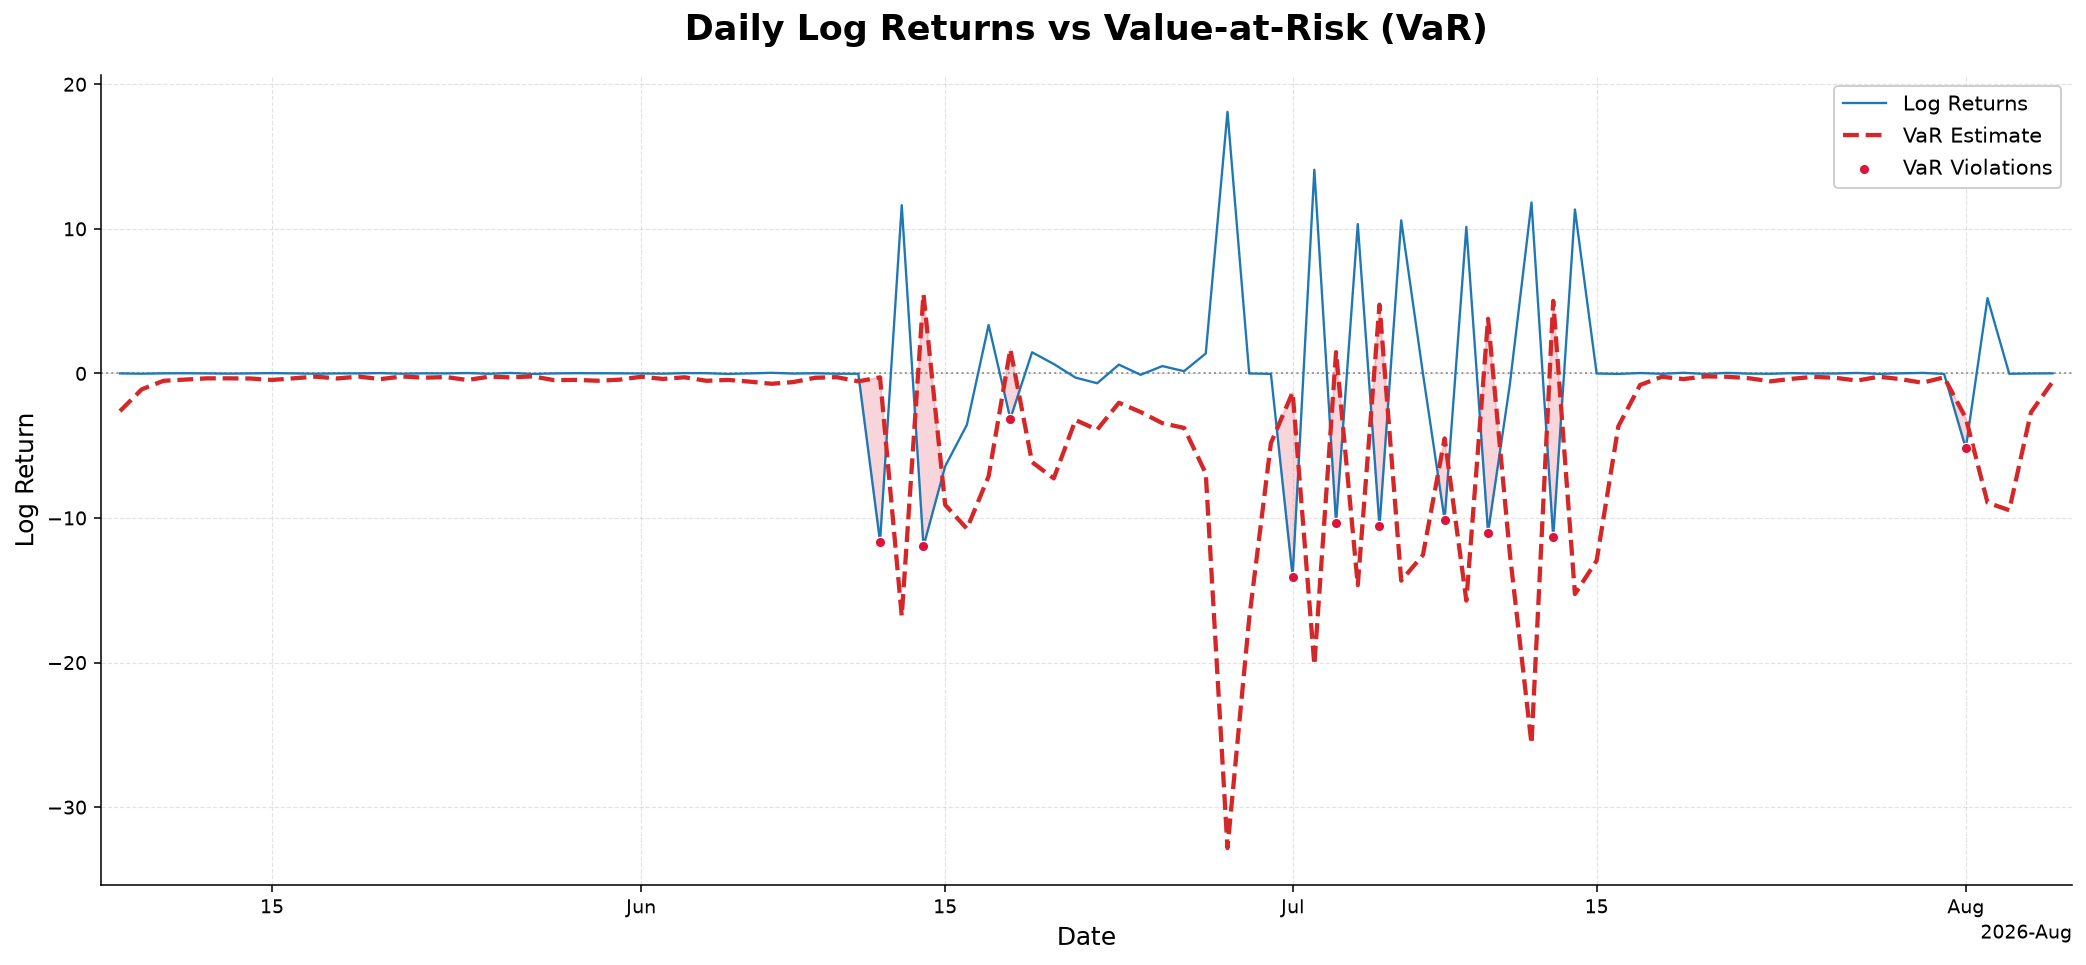

In [15]:
import pandas as pd
from utils.presentation import create_var_violation_plot

# -----------------------------
# Prepare data
# -----------------------------
dates = pd.to_datetime(log_returns["Date"].iloc[1:]).reset_index(drop=True)

create_var_violation_plot(dates, log_returns_np, var_estimates).show()